In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import zscore, skew
%matplotlib inline
plt.style.use('ggplot')

df = pd.read_csv(r"data\bank-additional-full.csv", sep=";")
df.head()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_27820\676564731.py:10: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"data\bank-additional-full.csv", sep=";")


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [2]:
df = df.rename(columns={'y': 'accepts'})

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  object 
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [5]:
num_cols = ['age', 'campaign', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed']
print("Even though pdays, previous and euribor3m are integers, we can consider them as categorical because they are encoded variables. So that's why we have num_cols.")

Even though pdays, previous and euribor3m are integers, we can consider them as categorical because they are encoded variables. So that's why we have num_cols.


In [6]:
print(df
    .isnull()
    .mean()
    *100)

print("\nNeeds to be <0.15% max to be acceptable, in this case this is a prepared dataset.")

age               0.0
job               0.0
marital           0.0
education         0.0
default           0.0
housing           0.0
loan              0.0
contact           0.0
month             0.0
day_of_week       0.0
duration          0.0
campaign          0.0
pdays             0.0
previous          0.0
poutcome          0.0
emp.var.rate      0.0
cons.price.idx    0.0
cons.conf.idx     0.0
euribor3m         0.0
nr.employed       0.0
accepts           0.0
dtype: float64

Needs to be <0.15% max to be acceptable, in this case this is a prepared dataset.


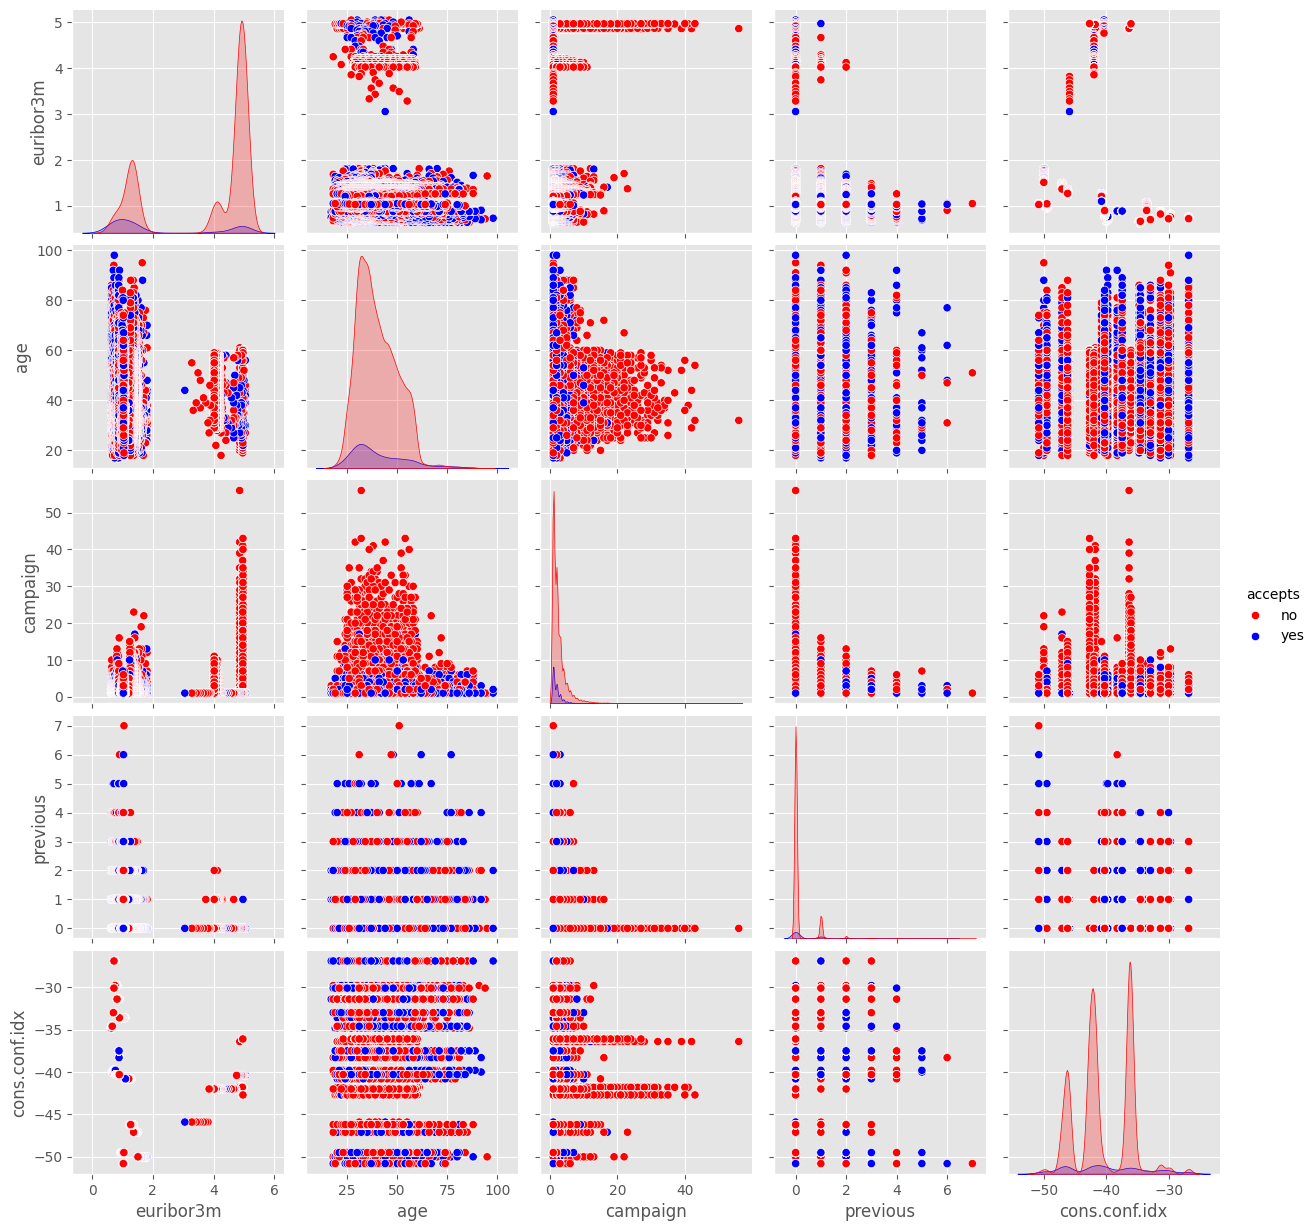

In [7]:
custom_pal = {
    "no": "red",
    "yes": "blue"
    }

sns.pairplot(df[['accepts', 'euribor3m', 'age', 'campaign', 'previous', 'cons.conf.idx']], hue = 'accepts', palette=custom_pal)

<Axes: >

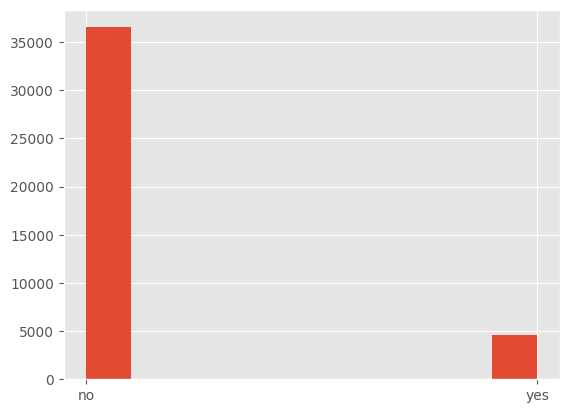

In [8]:
(df['accepts']).hist()

<Axes: >

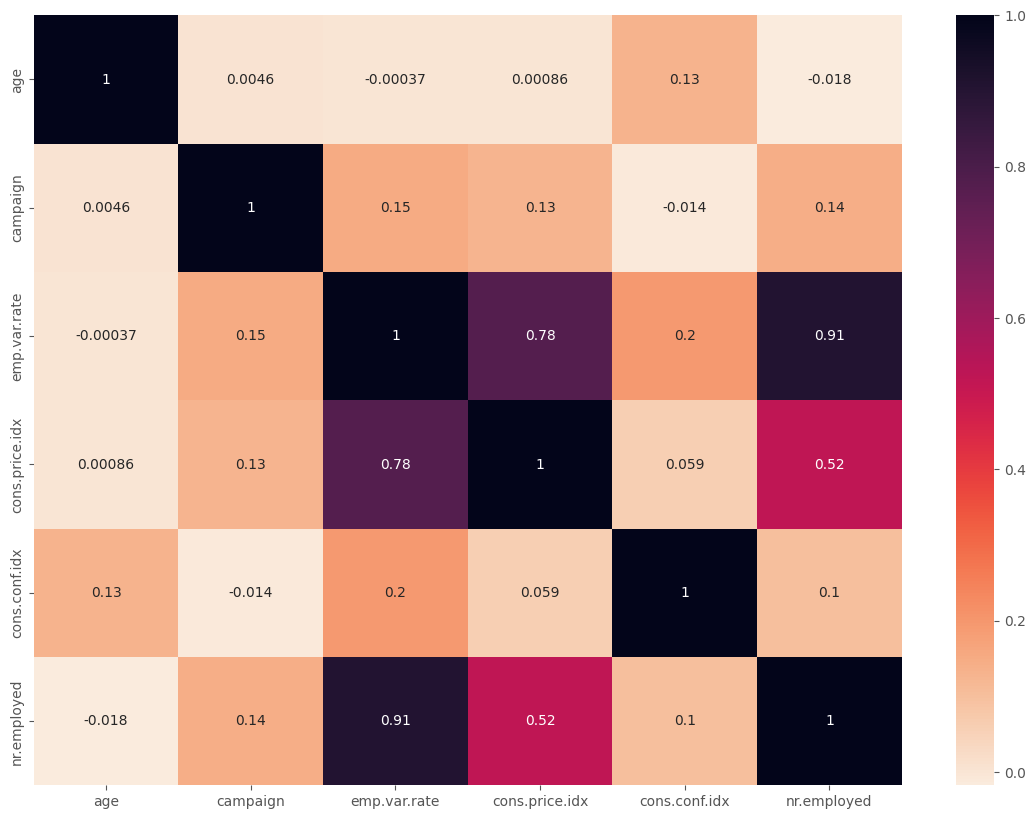

In [9]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df[num_cols]
    .corr(),
    annot=True, 
    cmap='rocket_r'
)

In [10]:
print("If correlation exceeds 0.8, there's a risk of multicollinearity. As you can see, there are some high-correlated variables here.")

If correlation exceeds 0.8, there's a risk of multicollinearity. As you can see, there are some high-correlated variables here.


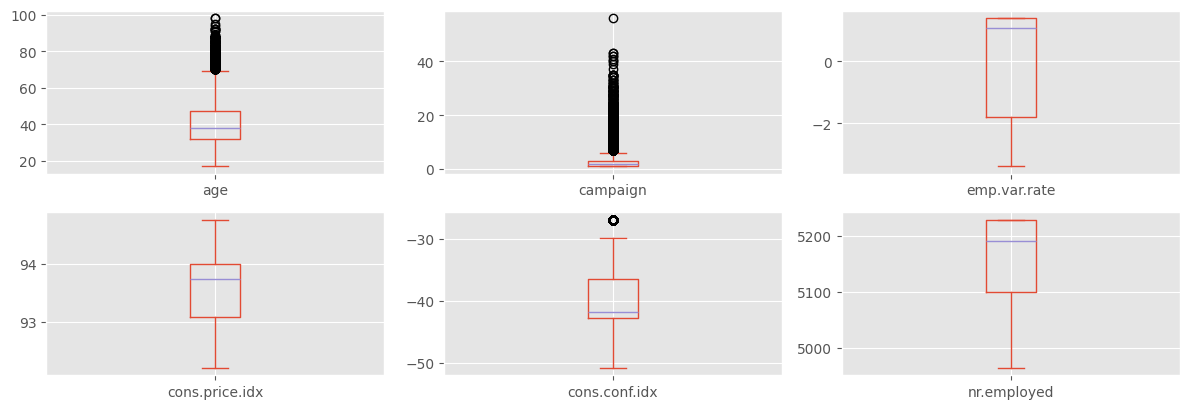

In age or campaign there are outliers that can bias the model, let's filter them!


In [11]:
df[num_cols].plot(kind='box', subplots=True, layout=(4, 3), figsize=(12, 8), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

print("In age or campaign there are outliers that can bias the model, let's filter them!")

In [12]:
df_filtered = df.copy()

for col in num_cols:
    Q1 = df_filtered[col].quantile(0.25)
    Q3 = df_filtered[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_filtered = df_filtered[ (df_filtered[col] >= lower_bound) & (df_filtered[col] <= upper_bound) ]

print(f"Original shape: {df.shape}")
print(f"Filtered shape: {df_filtered.shape}")
print(f"There was a total of {len(df) - len(df_filtered)} outliers")

Original shape: (41188, 21)
Filtered shape: (37935, 21)
There was a total of 3253 outliers


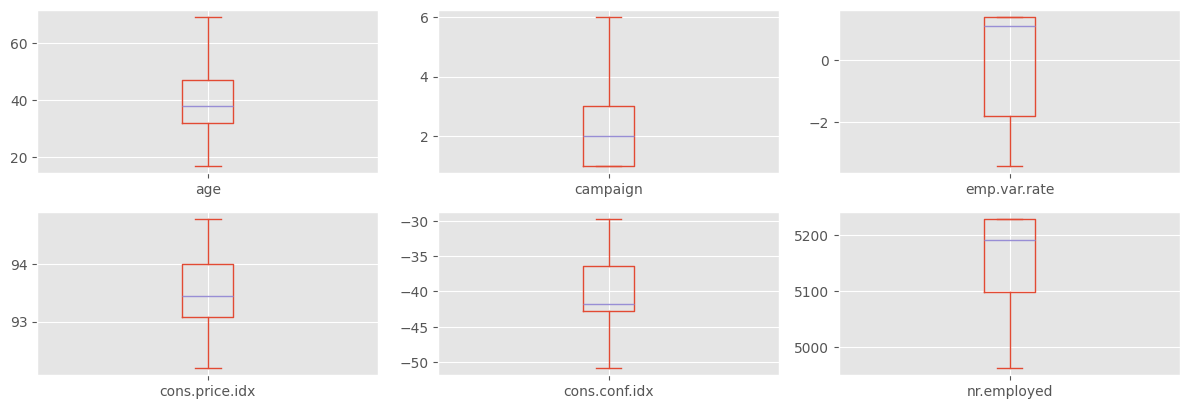

Now there is no outlier here. The data is clean.


In [13]:
df_outliers = df_filtered.drop(columns=['pdays', 'previous', 'euribor3m']).copy()

df_outliers.plot(kind='box', subplots=True, layout=(4, 3), figsize=(12, 8), sharex=False, sharey=False)
plt.tight_layout()
plt.show()
print("Now there is no outlier here. The data is clean.")

In [14]:
df_filtered.to_csv("data/cleaned_data.csv", index=False)

In [15]:
# Compara el antes y el después
print("Original Skew:\n", df[num_cols].skew())
print("\nFiltered Skew:\n", df_filtered[num_cols].skew())

print("\nOriginal Kurtosis:\n", df[num_cols].kurtosis())
print("\nFiltered Kurtosis:\n", df_filtered[num_cols].kurtosis())

Original Skew:
 age               0.784697
campaign          4.762507
emp.var.rate     -0.724096
cons.price.idx   -0.230888
cons.conf.idx     0.303180
nr.employed      -1.044262
dtype: float64

Filtered Skew:
 age               0.434411
campaign          1.293206
emp.var.rate     -0.702421
cons.price.idx   -0.192668
cons.conf.idx     0.129555
nr.employed      -1.065858
dtype: float64

Original Kurtosis:
 age                0.791312
campaign          36.979795
emp.var.rate      -1.062632
cons.price.idx    -0.829809
cons.conf.idx     -0.358558
nr.employed       -0.003760
dtype: float64

Filtered Kurtosis:
 age              -0.602656
campaign          1.044902
emp.var.rate     -1.115659
cons.price.idx   -0.839883
cons.conf.idx    -0.803765
nr.employed       0.130854
dtype: float64


In [16]:
print("REMINDER:")

print("\nValues close to 0 → symmetric distribution.")
print("Values > 1 or < -1 → high skewness.")

print("\nKurtosis ≈ 0 → similar to a normal distribution (mesokurtic)")
print("Kurtosis > 0 → heavy tails, more outliers (leptokurtic)")
print("Kurtosis < 0 → light tails, fewer outliers (platykurtic)")

REMINDER:

Values close to 0 → symmetric distribution.
Values > 1 or < -1 → high skewness.

Kurtosis ≈ 0 → similar to a normal distribution (mesokurtic)
Kurtosis > 0 → heavy tails, more outliers (leptokurtic)
Kurtosis < 0 → light tails, fewer outliers (platykurtic)
